## **ENIGH** - EDA Filtrado y Comparación de Modelos
* 18 de Marzo del 2025
#### ESCOM - IPN: *Modelado Predictivo*
#### Prof. Claudia Blanquel

#### *Lic. Ciencia de Datos* - 6AM1

> Armas Ramirez Daniel

> Gutierrez Ramirez Alana Sofia

> Hernández Peña Irving Jafet

> Reyes Maldonado Oscar Romario

> Sanchez Garcia Miguel Alexander

#### **0° Introducción**

Datos obtenidos de:

> https://www.inegi.org.mx/programas/enigh/nc/2016/#datos_abiertos

**a.** Como primer paso, necesitamos **importar** todas las **librerias** que usaremos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns

import scipy.stats as stats

from sklearn.preprocessing import PowerTransformer

# For PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import euclidean_distances

# For the random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Realizar predicciones
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Para la regresión logística
from sklearn.linear_model import LogisticRegression


**b.** Extraer la tabla necesaria de la base de datos

In [29]:
concentradohogar_df = pd.read_csv('datasets-ENIGH/conjunto_de_datos_concentradohogar_enigh_2016_ns/conjunto_de_datos/conjunto_de_datos_concentradohogar_enigh_2016_ns.csv')

In [30]:
concentradohogar_df.head()

,folioviv,foliohog,ubica_geo,ageb,tam_loc,est_socio,est_dis,upm,factor,clase_hog,sexo_jefe,edad_jefe,educa_jefe,tot_integ,hombres,mujeres,mayores,menores,p12_64,p65mas,ocupados,percep_ing,perc_ocupa,ing_cor,ingtrab,trabajo,sueldos,horas_extr,comisiones,aguinaldo,indemtrab,otra_rem,remu_espec,negocio,noagrop,industria,comercio,servicios,agrope,agricolas,pecuarios,reproducc,pesca,otros_trab,rentas,utilidad,arrenda,transfer,jubilacion,becas,donativos,remesas,bene_gob,transf_hog,trans_inst,estim_alqu,otros_ing,gasto_mon,alimentos,ali_dentro,cereales,carnes,pescado,leche,huevo,aceites,tuberculo,verduras,frutas,azucar,cafe,especias,otros_alim,bebidas,ali_fuera,tabaco,vesti_calz,vestido,calzado,vivienda,alquiler,pred_cons,agua,energia,limpieza,cuidados,utensilios,enseres,salud,atenc_ambu,hospital,medicinas,transporte,publico,foraneo,adqui_vehi,mantenim,refaccion,combus,comunica,educa_espa,educacion,esparci,paq_turist,personales,cuida_pers,acces_pers,otros_gas,transf_gas,percep_tot,retiro_inv,prestamos,otras_perc,ero_nm_viv,ero_nm_hog,erogac_tot,cuota_viv,mater_serv,material,servicio,deposito,prest_terc,pago_tarje,deudas,balance,otras_erog,smg
0,100003801,1,10010000,000-0,1,4,3,10,248,2,1,33,10,2,1,1,2,0,2,0,2,2,2,100696.70,100696.70,100696.70,97377.04,0.0,0.0,3319.66,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,46599.96,10621.89,9953.32,1763.94,1920.33,0.00,1130.13,0.00,0.00,0.00,154.28,488.56,449.99,0.0,1013.13,1580.13,1452.83,668.57,0.0,1888.03,1888.03,0.00,10543.5,8100.0,450.0,750.0,1243.5,15343.01,1425.0,0.00,13918.01,983.13,983.13,0.0,0.00,3450.00,0.0,0.00,0.0,2100.00,0.00,2100.0,1350.0,900.00,0.0,900.00,0.0,2870.40,1395.0,0.00,1475.40,0.00,0.00,0.0,0.0,0.0,0.0,0.00,17508.19,0.0,98.36,98.36,0.00,0.0,0.0,17409.83,0.0,0.0,0.0,6573.6
1,100003802,1,10010000,000-0,1,4,3,10,248,2,1,29,10,2,1,1,2,0,2,0,2,2,2,146616.16,144157.15,144157.15,91475.40,0.0,0.0,10819.67,0.0,7622.95,34239.13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2459.01,0.0,0.0,2459.01,0.0,0.0,0.0,0.0,0.0,0.0,82427.75,14637.70,6280.59,944.97,578.57,0.00,951.40,674.99,0.00,0.00,179.98,0.00,0.00,0.0,0.00,2774.54,176.14,8357.11,0.0,9415.70,5673.88,3741.82,9526.5,9000.0,0.0,291.0,235.5,8407.35,1524.0,342.39,6540.96,4397.26,1589.66,2807.6,0.00,10367.19,0.0,2754.08,0.0,5363.11,2213.11,3150.0,2250.0,2213.11,0.0,2213.11,0.0,18472.01,15303.0,3081.51,87.50,4990.93,880.43,0.0,0.0,0.0,0.0,880.43,5360.65,0.0,0.00,0.00,0.00,0.0,0.0,5360.65,0.0,0.0,0.0,6573.6
2,100003803,1,10010000,000-0,1,4,3,10,248,2,1,47,10,6,2,4,3,3,3,0,1,1,1,94622.95,82622.95,82622.95,82622.95,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,12000.0,0.0,54792.51,21214.07,13114.08,1877.10,2802.85,0.00,3381.40,244.28,334.28,192.85,1465.66,1465.68,0.00,0.0,0.00,514.28,835.70,8099.99,0.0,3463.01,2386.93,1076.08,930.0,0.0,0.0,630.0,300.0,9277.60,1206.0,694.56,7377.04,1447.82,0.00,0.0,1447.82,13050.00,0.0,0.00,0.0,9000.00,0.00,9000.0,4050.0,600.00,0.0,600.00,0.0,4810.01,1101.0,0.00,3709.01,0.00,0.00,0.0,0.0,0.0,0.0,0.00,23778.68,0.0,172.13,0.00,172.13,0.0,0.0,23606.55,0.0,0.0,0.0,6573.6
3,100003804,1,10010000,000-0,1,4,3,10,248,3,2,29,11,3,0,3,3,0,3,0,2,3,2,58278.65,34672.11,34672.11,33442.61,0.0,0.0,1229.50,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23606.54,0.0,0.0,23606.54,0.0,0.0,0.0,0.0,0.0,0.0,42452.37,14567.00,9938.43,1285.67,269.99,2571.42,899.99,629.99,0.00,0.00,411.41,0.00,0.00,0.0,0.00,3471.40,398.56,4628.57,0.0,782.60,0.00,782.60,15825.0,12000.0,0.0,600.0,3225.0,1905.00,1905.0,0.00,0.00,684.77,684.77,0.0,0.00,6420.00,0.0,0.00,0.0,1800.00,0.00,1800.0,4620.0,450.00,0.0,450.00,0.0,1818.00,1818.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.00,8852.45,0.0,0.00,0.00,0.00,0.0,0.0,8852.45,0.0,0.0,0.0,6573.6
4,100003805,1,10010000,000-0,1,4,3,10,248,2,1,55,10,2,2,0,2,0,2,0,1,1,1,57295.07,42295.07,42295.07,35409.83,0.0,0.0,6885.24,0.0,0.00,0.00,0.0,0.0,

In [85]:
# Imprimir el nombre de todas las columnas
df = concentradohogar_df.copy()
print("Columnas del DataFrame:")
for column in df.columns:
    print(column)

Columnas del DataFrame:
folioviv
foliohog
ubica_geo
ageb
tam_loc
est_socio
est_dis
upm
factor
clase_hog
sexo_jefe
edad_jefe
educa_jefe
tot_integ
hombres
mujeres
mayores
menores
p12_64
p65mas
ocupados
percep_ing
perc_ocupa
ing_cor
ingtrab
trabajo
sueldos
horas_extr
comisiones
aguinaldo
indemtrab
otra_rem
remu_espec
negocio
noagrop
industria
comercio
servicios
agrope
agricolas
pecuarios
reproducc
pesca
otros_trab
rentas
utilidad
arrenda
transfer
jubilacion
becas
donativos
remesas
bene_gob
transf_hog
trans_inst
estim_alqu
otros_ing
gasto_mon
alimentos
ali_dentro
cereales
carnes
pescado
leche
huevo
aceites
tuberculo
verduras
frutas
azucar
cafe
especias
otros_alim
bebidas
ali_fuera
tabaco
vesti_calz
vestido
calzado
vivienda
alquiler
pred_cons
agua
energia
limpieza
cuidados
utensilios
enseres
salud
atenc_ambu
hospital
medicinas
transporte
publico
foraneo
adqui_vehi
mantenim
refaccion
combus
comunica
educa_espa
educacion
esparci
paq_turist
personales
cuida_pers
acces_pers
otros_gas
transf_gas

In [86]:
# Seleccionar las columnas de interés
columnas_interes = ['folioviv', 'foliohog', 'ubica_geo', 'ageb', 'tam_loc', 'est_socio', 'est_dis', 'upm', 'factor', 'clase_hog',
                     'sexo_jefe', 'edad_jefe', 'educa_jefe', 'tot_integ', 'hombres', 'mujeres', 'mayores', 'menores', 'p12_64', 
                     'p65mas', 'ocupados', 'percep_ing', 'perc_ocupa', 'ing_cor', 'gasto_mon', 'percep_tot', 'erogac_tot' ]
df = concentradohogar_df[columnas_interes]

# Eliminar filas con valores nulos
df = df.dropna()

# Eliminar filas con valores duplicados
df = df.drop_duplicates()


In [87]:
correlation = df[['percep_tot', 'ing_cor']].corr()
print(correlation)

# Definir la variable objetivo (endeudamiento)
df['endeudamiento'] = np.where((df['percep_tot'] + df['ing_cor']) < (df['erogac_tot'] + df['gasto_mon']), 1, 0)
# Eliminar las columnas que no son necesarias para el análisis
df = df.drop(columns=['percep_tot', 'erogac_tot'])

# Eliminar columnas que no son necesarias para el análisis
df = df.drop(columns=['folioviv', 'foliohog', 'ubica_geo', 'ageb', 'est_dis', 'upm', 'factor', 'clase_hog', 'ing_cor', 'gasto_mon'])

print("Columnas del DataFrame después de la limpieza:")
for column in df.columns:
    print(column)

            percep_tot   ing_cor
percep_tot    1.000000  0.039111
ing_cor       0.039111  1.000000
Columnas del DataFrame después de la limpieza:
tam_loc
est_socio
sexo_jefe
edad_jefe
educa_jefe
tot_integ
hombres
mujeres
mayores
menores
p12_64
p65mas
ocupados
percep_ing
perc_ocupa
endeudamiento


In [88]:
# Manejar el desbalance de clases
from sklearn.utils import resample

# Separar las clases mayoritarias y minoritarias
mayoria = df[df['endeudamiento'] == 0]
minoria = df[df['endeudamiento'] == 1]

# Submuestreo de la clase mayoritaria
mayoria_submuestreo = resample(mayoria, replace=False, n_samples=len(minoria), random_state=21)

# Combinar la clase minoritaria con la clase mayoritaria submuestreada
df_balanced = pd.concat([mayoria_submuestreo, minoria])
# Mezclar el DataFrame balanceado
df_balanced = df_balanced.sample(frac=1, random_state=21).reset_index(drop=True)

In [89]:
# Preparar los datos para clasificación
X = df_balanced.drop(columns=['endeudamiento'])
y = df_balanced['endeudamiento']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

# Definir el modelo de Regresión Logística
logistic_model = LogisticRegression(max_iter=1000, random_state=21)

# Entrenar el modelo
logistic_model.fit(X_train, y_train)

# Realizar predicciones
y_pred = logistic_model.predict(X_test)

# Evaluar el modelo
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))

# Imprimir los coeficientes del modelo
for feature, coef in zip(X.columns, logistic_model.coef_[0]):
    print(f"{coef:.4f} ({feature})")

# Intercepto del modelo
print(f"Intercepto: {logistic_model.intercept_[0]:.4f}")

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.60      0.54      0.56      2685
           1       0.56      0.62      0.59      2567

    accuracy                           0.58      5252
   macro avg       0.58      0.58      0.58      5252
weighted avg       0.58      0.58      0.58      5252

0.0453 (tam_loc)
-0.0937 (est_socio)
-0.1124 (sexo_jefe)
-0.0131 (edad_jefe)
0.0159 (educa_jefe)
0.0085 (tot_integ)
0.0001 (hombres)
0.0084 (mujeres)
-0.0170 (mayores)
0.0255 (menores)
0.0769 (p12_64)
-0.0939 (p65mas)
0.3083 (ocupados)
-0.0062 (percep_ing)
-0.6044 (perc_ocupa)
Intercepto: 1.0439


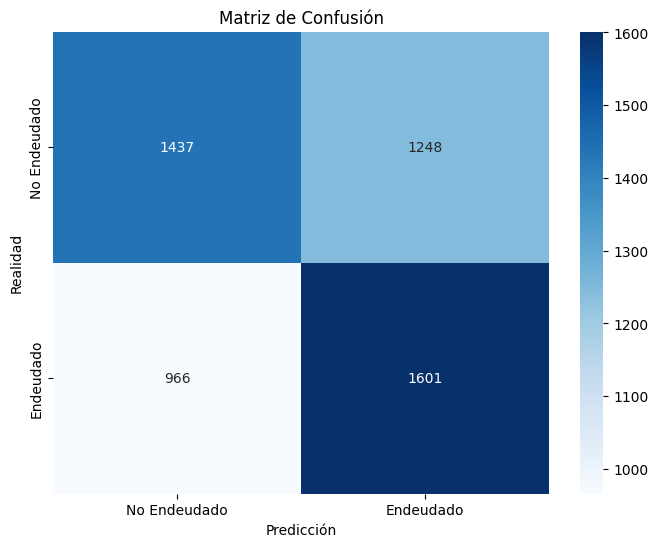

In [90]:
# Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Endeudado', 'Endeudado'], yticklabels=['No Endeudado', 'Endeudado'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.show()


Características más importantes:
       feature  importance
3    edad_jefe    0.334153
4   educa_jefe    0.149441
0      tam_loc    0.074808
13  percep_ing    0.064605
1    est_socio    0.061968
7      mujeres    0.046898
6      hombres    0.045164
5    tot_integ    0.033533
12    ocupados    0.032287
14  perc_ocupa    0.031551


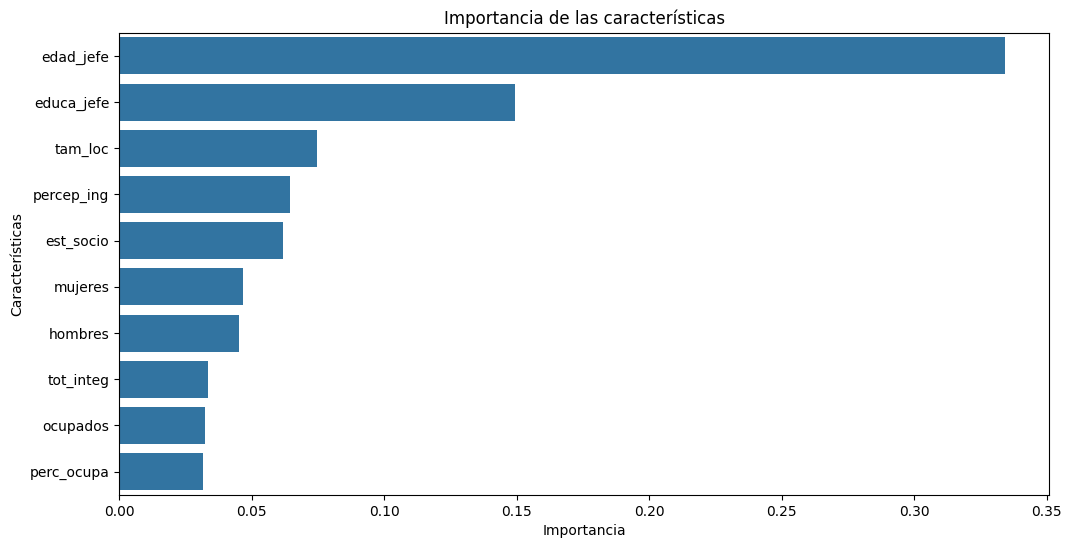

In [91]:
# Buscar las mejores características usando Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=21)
rf.fit(X_train, y_train)
# Obtener las importancias de las características
importances = rf.feature_importances_
# Crear un DataFrame para las importancias
feature_importances = pd.DataFrame({'feature': X.columns, 'importance': importances})
# Ordenar las importancias de mayor a menor
feature_importances = feature_importances.sort_values(by='importance', ascending=False)
# Mostrar las 10 características más importantes
print("Características más importantes:")
print(feature_importances.head(10))
# Graficar las importancias de las características
plt.figure(figsize=(12, 6))
sns.barplot(x='importance', y='feature', data=feature_importances.head(10))
plt.title('Importancia de las características')
plt.xlabel('Importancia')
plt.ylabel('Características')
plt.show()

In [92]:
# Bosque Aleatorio
# Definir el modelo de Bosque Aleatorio
rf_model = RandomForestClassifier(n_estimators=20, random_state=21)
# Entrenar el modelo
rf_model.fit(X_train, y_train)
# Realizar predicciones
y_pred_rf = rf_model.predict(X_test)
# Evaluar el modelo
print("\nReporte de clasificación del Bosque Aleatorio:")
print(classification_report(y_test, y_pred_rf))


Reporte de clasificación del Bosque Aleatorio:
              precision    recall  f1-score   support

           0       0.56      0.57      0.56      2685
           1       0.54      0.53      0.54      2567

    accuracy                           0.55      5252
   macro avg       0.55      0.55      0.55      5252
weighted avg       0.55      0.55      0.55      5252

